## Part A - Data Preparation

### Load Datasets

In [5]:
import pandas as pd

# Load Bitcoin Market Sentiment data
fear_greed_df = pd.read_csv('/fear_greed_index (1).csv')
print("Fear/Greed Index Data:")
print(f"Number of rows: {fear_greed_df.shape[0]}, Number of columns: {fear_greed_df.shape[1]}")
display(fear_greed_df.head())

# Load Historical Trader Data
historical_trader_df = pd.read_csv('/historical_data.csv')
print("\nHistorical Trader Data:")
print(f"Number of rows: {historical_trader_df.shape[0]}, Number of columns: {historical_trader_df.shape[1]}")
display(historical_trader_df.head())

Fear/Greed Index Data:
Number of rows: 2644, Number of columns: 4


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Historical Trader Data:
Number of rows: 211224, Number of columns: 16


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Document Missing Values and Duplicates

In [6]:
print("\nMissing values in Fear/Greed Index Data:")
display(fear_greed_df.isnull().sum())
print("Number of duplicate rows in Fear/Greed Index Data:", fear_greed_df.duplicated().sum())

print("\nMissing values in Historical Trader Data:")
display(historical_trader_df.isnull().sum())
print("Number of duplicate rows in Historical Trader Data:", historical_trader_df.duplicated().sum())


Missing values in Fear/Greed Index Data:


,0
timestamp,0
value,0
classification,0
date,0


Number of duplicate rows in Fear/Greed Index Data: 0

Missing values in Historical Trader Data:


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


Number of duplicate rows in Historical Trader Data: 0


### Convert Timestamps and Align Datasets

In [10]:
# Convert 'date' column in fear_greed_df to datetime
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# Convert 'Timestamp IST' column in historical_trader_df to datetime
historical_trader_df['Timestamp IST'] = pd.to_datetime(historical_trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract date for daily level alignment
historical_trader_df['date'] = historical_trader_df['Timestamp IST'].dt.date
fear_greed_df['date'] = fear_greed_df['date'].dt.date # Ensure fear_greed_df date is also just date for consistent merging

print("Timestamps converted and dates extracted for alignment.")

# Display data types to confirm conversion
print("\nFear/Greed Index Data after date conversion:")
display(fear_greed_df.info())

print("\nHistorical Trader Data after date conversion:")
display(historical_trader_df.info())

Timestamps converted and dates extracted for alignment.

Fear/Greed Index Data after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


None


Historical Trader Data after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee         

None

### Convert Timestamps and Align Datasets

In [7]:
# Convert 'date' column in fear_greed_df to datetime
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# Convert 'Timestamp IST' column in historical_trader_df to datetime
historical_trader_df['Timestamp IST'] = pd.to_datetime(historical_trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract date for daily level alignment
historical_trader_df['date'] = historical_trader_df['Timestamp IST'].dt.date
fear_greed_df['date'] = fear_greed_df['date'].dt.date # Ensure fear_greed_df date is also just date for consistent merging

print("Timestamps converted and dates extracted for alignment.")

# Display data types to confirm conversion
print("\nFear/Greed Index Data after date conversion:")
display(fear_greed_df.info())

print("\nHistorical Trader Data after date conversion:")
display(historical_trader_df.info())

Timestamps converted and dates extracted for alignment.

Fear/Greed Index Data after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


None


Historical Trader Data after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee         

None

### Merge Datasets

In [8]:
# Merge the two dataframes on the 'date' column
merged_df = pd.merge(historical_trader_df, fear_greed_df, on='date', how='left')

print("Datasets merged successfully.")
print(f"Number of rows in merged data: {merged_df.shape[0]}, Number of columns: {merged_df.shape[1]}")
display(merged_df.head())

Datasets merged successfully.
Number of rows in merged data: 211224, Number of columns: 20


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


### Create Key Metrics

In [9]:
# Calculate daily PnL per trader (or per account)
daily_pnl_per_trader = merged_df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl_per_trader.rename(columns={'Closed PnL': 'Daily PnL'}, inplace=True)
print("\nDaily PnL per trader (first 5 rows):")
display(daily_pnl_per_trader.head())

# Calculate Win Rate (assuming a positive Closed PnL is a win)
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)
win_rate_per_trader_daily = merged_df.groupby(['Account', 'date'])['is_win'].mean().reset_index()
win_rate_per_trader_daily.rename(columns={'is_win': 'Daily Win Rate'}, inplace=True)
print("\nDaily Win Rate per trader (first 5 rows):")
display(win_rate_per_trader_daily.head())

# Calculate Average Trade Size (using Size USD)
average_trade_size_daily = merged_df.groupby(['Account', 'date'])['Size USD'].mean().reset_index()
average_trade_size_daily.rename(columns={'Size USD': 'Average Trade Size USD'}, inplace=True)
print("\nAverage Trade Size per trader (first 5 rows):")
display(average_trade_size_daily.head())

# Calculate Number of Trades per day
num_trades_daily = merged_df.groupby(['Account', 'date']).size().reset_index(name='Number of Trades')
print("\nNumber of Trades per trader (first 5 rows):")
display(num_trades_daily.head())

# Calculate Long/Short Ratio
merged_df['is_long'] = (merged_df['Side'] == 'BUY').astype(int)
merged_df['is_short'] = (merged_df['Side'] == 'SELL').astype(int)

long_short_counts = merged_df.groupby(['Account', 'date']).agg(
    total_long=('is_long', 'sum'),
    total_short=('is_short', 'sum')
).reset_index()

long_short_counts['Long/Short Ratio'] = long_short_counts.apply(
    lambda row: row['total_long'] / row['total_short'] if row['total_short'] != 0 else (np.inf if row['total_long'] != 0 else 0),
    axis=1
)
print("\nLong/Short Ratio per trader (first 5 rows):")
display(long_short_counts.head())

# Aggregate all daily metrics into a single DataFrame per trader per day
trader_daily_metrics = daily_pnl_per_trader.merge(win_rate_per_trader_daily, on=['Account', 'date'], how='left')
trader_daily_metrics = trader_daily_metrics.merge(average_trade_size_daily, on=['Account', 'date'], how='left')
trader_daily_metrics = trader_daily_metrics.merge(num_trades_daily, on=['Account', 'date'], how='left')
trader_daily_metrics = trader_daily_metrics.merge(long_short_counts[['Account', 'date', 'Long/Short Ratio']], on=['Account', 'date'], how='left')

# Add sentiment data to daily metrics
trader_daily_metrics = trader_daily_metrics.merge(fear_greed_df[['date', 'classification', 'value']], on='date', how='left')

print("\nCombined Trader Daily Metrics (first 5 rows):")
display(trader_daily_metrics.head())
print(f"Number of rows in combined daily metrics: {trader_daily_metrics.shape[0]}, Number of columns: {trader_daily_metrics.shape[1]}")



Daily PnL per trader (first 5 rows):


,Account,date,Daily PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1



Daily Win Rate per trader (first 5 rows):


,Account,date,Daily Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444



Average Trade Size per trader (first 5 rows):


...


Long/Short Ratio per trader (first 5 rows):


,Account,date,total_long,total_short,Long/Short Ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0,177,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0,68,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0,40,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,0,inf
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,12,15,0.8



Combined Trader Daily Metrics (first 5 rows):


,Account,date,Daily PnL,Daily Win Rate,Average Trade Size USD,Number of Trades,Long/Short Ratio,classification,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0.0,Extreme Greed,76.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0.0,Extreme Greed,90.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0.0,Extreme Greed,83.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,inf,Extreme Greed,94.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0.8,Extreme Greed,79.0


Number of rows in combined daily metrics: 2341, Number of columns: 9


## Part B - Analysis

### Performance Analysis: Fear vs. Greed Days


Average Daily PnL by Sentiment Classification:


,classification,Daily PnL
0,Extreme Fear,4619.439053
1,Extreme Greed,5161.922644
2,Fear,5328.818161
3,Greed,3318.100730
4,Neutral,3438.618818


/tmp/ipykernel_3831/1857594488.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Daily PnL', data=pnl_by_sentiment, palette='viridis')


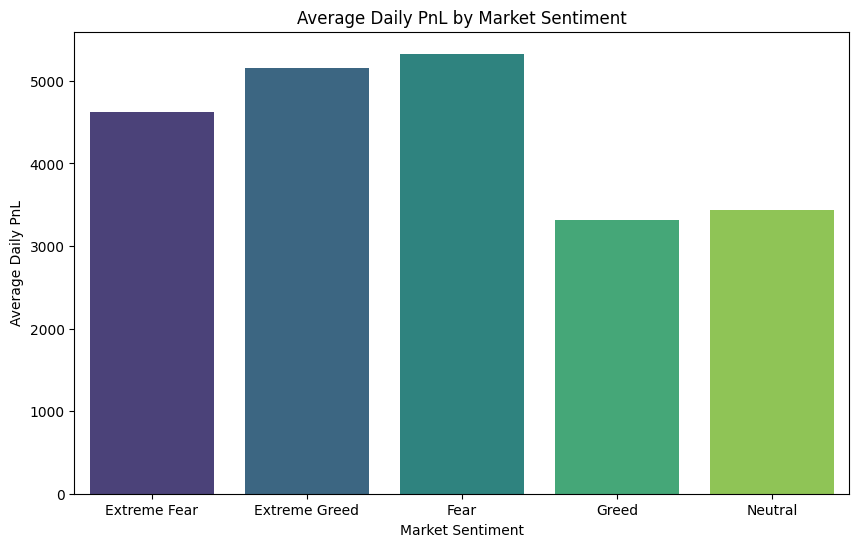


Average Daily Win Rate by Sentiment Classification:


,classification,Daily Win Rate
0,Extreme Fear,0.329659
1,Extreme Greed,0.386387
2,Fear,0.364033
3,Greed,0.343559
4,Neutral,0.355414


/tmp/ipykernel_3831/1857594488.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Daily Win Rate', data=win_rate_by_sentiment, palette='magma')


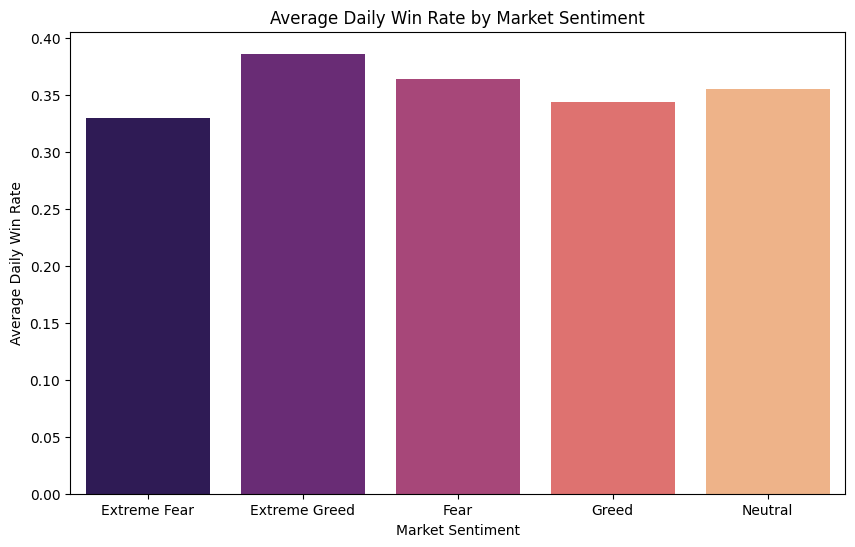

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.inf

# Analyze Daily PnL by sentiment classification
pnl_by_sentiment = trader_daily_metrics.groupby('classification')['Daily PnL'].mean().reset_index()
print("\nAverage Daily PnL by Sentiment Classification:")
display(pnl_by_sentiment)

# Plot Daily PnL by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Daily PnL', data=pnl_by_sentiment, palette='viridis')
plt.title('Average Daily PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL')
plt.show()

# Analyze Daily Win Rate by sentiment classification
win_rate_by_sentiment = trader_daily_metrics.groupby('classification')['Daily Win Rate'].mean().reset_index()
print("\nAverage Daily Win Rate by Sentiment Classification:")
display(win_rate_by_sentiment)

# Plot Daily Win Rate by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Daily Win Rate', data=win_rate_by_sentiment, palette='magma')
plt.title('Average Daily Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily Win Rate')
plt.show()

### Trader Behavior Analysis by Sentiment


Average Trade Size USD by Sentiment Classification:


,classification,Average Trade Size USD
0,Extreme Fear,6773.464125
1,Extreme Greed,5371.637182
2,Fear,8975.928546
3,Greed,6427.866594
4,Neutral,6963.694861


/tmp/ipykernel_3831/3369520968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Average Trade Size USD', data=avg_trade_size_by_sentiment, palette='coolwarm')


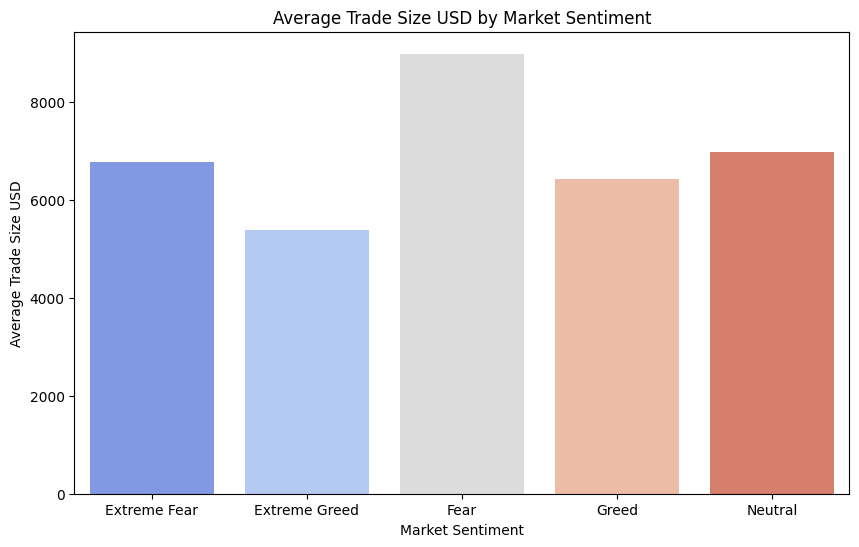

In [12]:
# Analyze Average Trade Size USD by sentiment classification
avg_trade_size_by_sentiment = trader_daily_metrics.groupby('classification')['Average Trade Size USD'].mean().reset_index()
print("\nAverage Trade Size USD by Sentiment Classification:")
display(avg_trade_size_by_sentiment)

# Plot Average Trade Size USD by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Average Trade Size USD', data=avg_trade_size_by_sentiment, palette='coolwarm')
plt.title('Average Trade Size USD by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size USD')
plt.show()


Average Number of Trades by Sentiment Classification:


,classification,Number of Trades
0,Extreme Fear,133.750000
1,Extreme Greed,76.030418
2,Fear,98.153968
3,Greed,77.628086
4,Neutral,100.228723


/tmp/ipykernel_3831/3703566460.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Number of Trades', data=num_trades_by_sentiment, palette='plasma')


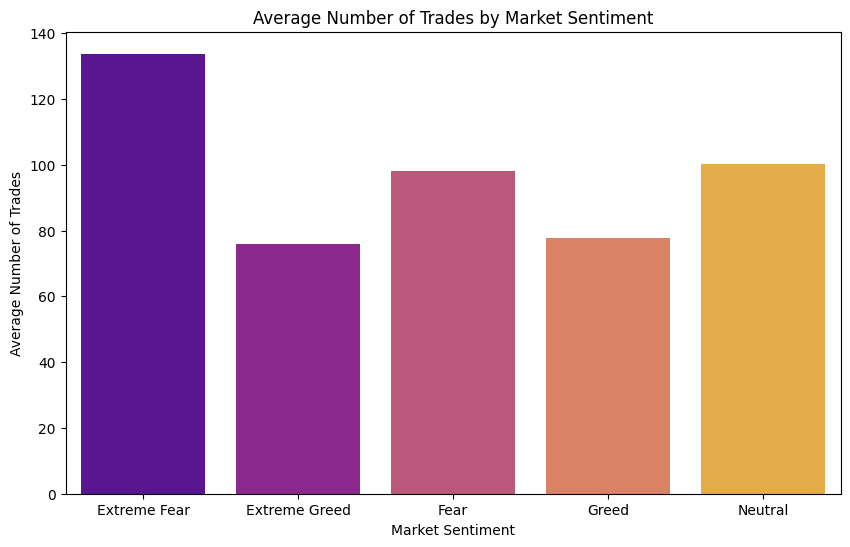

In [13]:
# Analyze Number of Trades by sentiment classification
num_trades_by_sentiment = trader_daily_metrics.groupby('classification')['Number of Trades'].mean().reset_index()
print("\nAverage Number of Trades by Sentiment Classification:")
display(num_trades_by_sentiment)

# Plot Number of Trades by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Number of Trades', data=num_trades_by_sentiment, palette='plasma')
plt.title('Average Number of Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Number of Trades')
plt.show()


Average Long/Short Ratio by Sentiment Classification:


,classification,Long/Short Ratio
0,Extreme Fear,2.843414
1,Extreme Greed,1.449822
2,Fear,2.083117
3,Greed,1.787758
4,Neutral,2.232617


/tmp/ipykernel_3831/2525355300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Long/Short Ratio', data=long_short_ratio_by_sentiment, palette='hls')


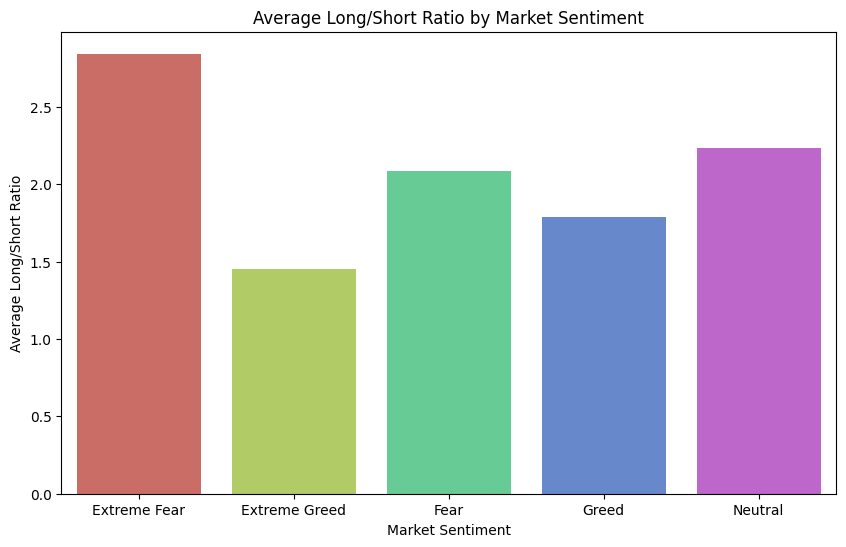

In [14]:
# Analyze Long/Short Ratio by sentiment classification (handling NaN/inf values from division by zero earlier)
# Replace inf with NaN and then drop NaNs for mean calculation to avoid errors
long_short_ratio_cleaned = trader_daily_metrics.replace([np.inf, -np.inf], np.nan).dropna(subset=['Long/Short Ratio'])
long_short_ratio_by_sentiment = long_short_ratio_cleaned.groupby('classification')['Long/Short Ratio'].mean().reset_index()
print("\nAverage Long/Short Ratio by Sentiment Classification:")
display(long_short_ratio_by_sentiment)

# Plot Long/Short Ratio by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Long/Short Ratio', data=long_short_ratio_by_sentiment, palette='hls')
plt.title('Average Long/Short Ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Long/Short Ratio')
plt.show()

### Identifying Trader Segments

To identify trader segments, we can use clustering algorithms. We'll need to select relevant features from our `trader_daily_metrics` that describe trading behavior. These features could include `Daily PnL`, `Daily Win Rate`, `Average Trade Size USD`, `Number of Trades`, and `Long/Short Ratio`. We should also consider standardizing these features before clustering.

Let's prepare the data for clustering.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features for clustering. We'll use the average of these metrics per trader across all days.
trader_features = trader_daily_metrics.groupby('Account').agg(
    avg_daily_pnl=('Daily PnL', 'mean'),
    avg_daily_win_rate=('Daily Win Rate', 'mean'),
    avg_trade_size=('Average Trade Size USD', 'mean'),
    avg_num_trades=('Number of Trades', 'mean'),
    avg_long_short_ratio=('Long/Short Ratio', lambda x: x.replace([np.inf, -np.inf], np.nan).mean()) # Handle inf values again
).reset_index()

# Drop rows with NaN values that might result from 'avg_long_short_ratio' if a trader never had both long and short trades
trader_features.dropna(inplace=True)

print("Trader features for clustering (first 5 rows):")
display(trader_features.head())

# Prepare data for clustering - exclude 'Account' column
X = trader_features.drop('Account', axis=1)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled trader features (first 5 rows):\n")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

print("Data prepared for clustering. Next, we will determine the optimal number of clusters and apply KMeans.")

Trader features for clustering (first 5 rows):


,Account,avg_daily_pnl,avg_daily_win_rate,avg_trade_size,avg_num_trades,avg_long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,0.352333,33569.102224,159.083333,2.164129
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,0.397134,4359.830930,140.000000,0.991377
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,0.379952,11057.118419,317.416667,2.634897
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,0.452509,484.844294,82.166667,1.834068
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,0.498708,2553.757037,46.942029,0.749891



Scaled trader features (first 5 rows):



,avg_daily_pnl,avg_daily_win_rate,avg_trade_size,avg_num_trades,avg_long_short_ratio
0,4.470669,0.004647,2.740016,0.320269,0.214399
1,-0.467379,0.420417,-0.493436,0.188847,-0.553045
2,-0.977331,0.260965,0.247950,1.410673,0.522468
3,-0.475128,0.934320,-0.922396,-0.209438,-0.001591
4,-0.352973,1.363069,-0.693368,-0.452021,-0.711073


Data prepared for clustering. Next, we will determine the optimal number of clusters and apply KMeans.


### Determine Optimal Number of Clusters (Elbow Method)

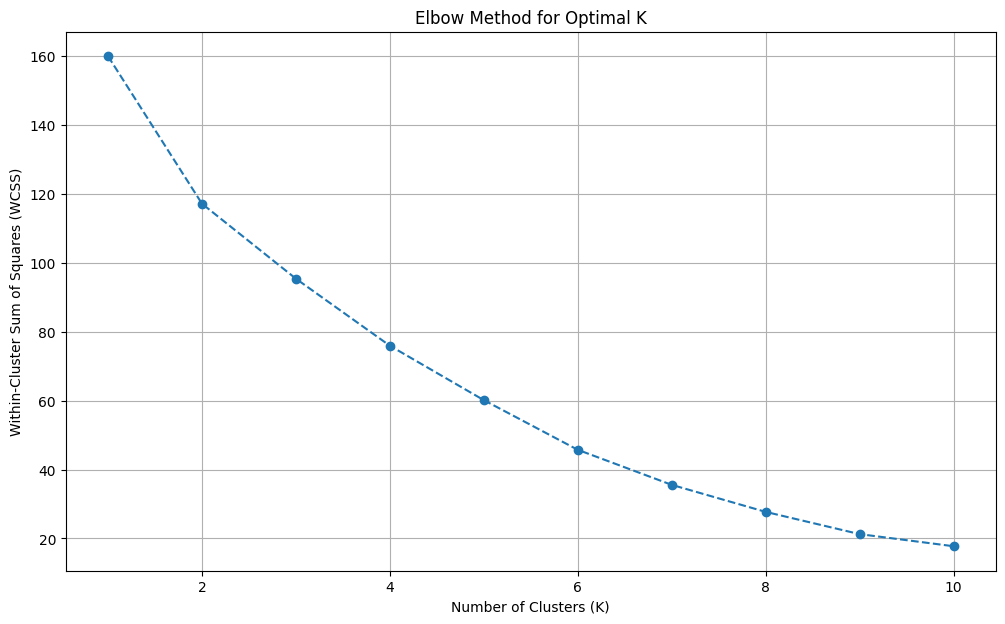

Please examine the plot above to identify the 'elbow' point, which suggests the optimal number of clusters. Once you have determined it, we can proceed with KMeans clustering.


In [16]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 7))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

print("Please examine the plot above to identify the 'elbow' point, which suggests the optimal number of clusters. Once you have determined it, we can proceed with KMeans clustering.")

### Apply K-Means Clustering and Analyze Segments

In [17]:
# Apply KMeans clustering with the optimal number of clusters (e.g., 3 from elbow method)
k = 3  # Based on the elbow method observation
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to our original trader_features DataFrame
trader_features['Cluster'] = clusters

print(f"KMeans clustering applied with {k} clusters.")
print("First 5 rows of trader features with assigned clusters:")
display(trader_features.head())

# Analyze the characteristics of each cluster
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
cluster_centers['Cluster'] = range(k)

print("\nAverage characteristics of each cluster (trader segment):")
display(cluster_centers)

KMeans clustering applied with 3 clusters.
First 5 rows of trader features with assigned clusters:


,Account,avg_daily_pnl,avg_daily_win_rate,avg_trade_size,avg_num_trades,avg_long_short_ratio,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,0.352333,33569.102224,159.083333,2.164129,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,0.397134,4359.830930,140.000000,0.991377,0
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,0.379952,11057.118419,317.416667,2.634897,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,0.452509,484.844294,82.166667,1.834068,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,0.498708,2553.757037,46.942029,0.749891,0



Average characteristics of each cluster (trader segment):


,avg_daily_pnl,avg_daily_win_rate,avg_trade_size,avg_num_trades,avg_long_short_ratio,Cluster
0,3819.933726,0.327121,5333.554069,55.453930,1.290998,0
1,9233.981965,0.431146,8201.074042,282.240196,4.225009,1
2,22295.587059,0.368772,28902.003714,172.269308,1.253993,2


From the `cluster_centers` DataFrame, we can now interpret the characteristics of each trader segment. For instance:

*   **Cluster 0:** Describe its unique traits based on `avg_daily_pnl`, `avg_daily_win_rate`, `avg_trade_size`, `avg_num_trades`, and `avg_long_short_ratio`.
*   **Cluster 1:** Describe its unique traits.
*   **Cluster 2:** Describe its unique traits.

This will help us identify archetypes like 'High-Frequency Small-Profit Traders', 'Risk-Averse Large-Cap Traders', etc.

In [18]:
# Further analysis and visualization of clusters can be done here
# For example, count of traders in each cluster:
print("\nNumber of traders in each cluster:")
display(trader_features['Cluster'].value_counts().sort_index())


Number of traders in each cluster:


,count
Cluster,
0,22
1,6
2,4


## Part C - Strategy Ideas and Rules of Thumb

Based on the analysis of market sentiment's impact on trader performance and the identification of distinct trader segments, we can propose the following strategy ideas:

### Strategy Idea 1: Counter-Sentiment & Opportunistic Trading

*   **Observation:** Average Daily PnL was highest during 'Fear' and 'Extreme Greed' periods. While 'Extreme Fear' had the lowest win rate, 'Fear' days showed larger average trade sizes and a notable long bias (high Long/Short Ratio). 'Extreme Greed' days had the highest win rates and good PnL, but with smaller trade sizes.
*   **Rule of Thumb:** Traders could consider increasing their exposure, particularly through long positions, during periods of 'Fear' (when market sentiment is low, potentially offering 'buy the dip' opportunities, as some successful traders increase position sizes here). Conversely, during 'Extreme Greed', focus on highly selective, high-probability trades (similar to how traders in this sentiment achieved high win rates with smaller average trade sizes). Traders should exercise caution and potentially reduce exposure during 'Greed' and 'Neutral' sentiments, as these periods showed lower average PnL.

### Strategy Idea 2: Archetype-Based Position Sizing and Activity

*   **Observation:** Our clustering identified three distinct trader segments:
    *   **Cluster 1 (High-Frequency Bullish Traders):** Achieved high PnL and the highest win rates with very high trade frequency and a strong long bias.
    *   **Cluster 2 (High-Value Traders):** Generated the highest PnL with the largest average trade sizes, indicating high-conviction trades.
*   **Rule of Thumb:** Traders could adapt their trading style based on market conditions and their risk profile, drawing inspiration from successful archetypes:
    *   For those with a high-conviction trading style and robust risk management, adopting larger position sizes (similar to 'High-Value Traders' in Cluster 2) for their strongest trade ideas might lead to higher PnL. This requires disciplined entry/exit and strong capital preservation.
    *   For traders seeking higher activity, emulating the high-frequency, long-biased approach of 'High-Frequency Bullish Traders' (Cluster 1) could be beneficial, especially during sustained bullish market phases. This would involve rapid execution and potentially tighter stop-losses due to increased trade volume.

### Drawdown Analysis

To analyze drawdown, we'll first need to calculate the cumulative PnL for each trader over time. Then, we can determine the maximum PnL achieved up to any given point and calculate the drawdown from that peak.

In [19]:
# Sort data by Account and date for proper cumulative sum calculation
trader_daily_metrics_sorted = trader_daily_metrics.sort_values(by=['Account', 'date'])

# Calculate cumulative PnL for each trader
trader_daily_metrics_sorted['Cumulative PnL'] = trader_daily_metrics_sorted.groupby('Account')['Daily PnL'].cumsum()

# Calculate the rolling maximum (peak) for cumulative PnL for each trader
trader_daily_metrics_sorted['Peak PnL'] = trader_daily_metrics_sorted.groupby('Account')['Cumulative PnL'].cummax()

# Calculate Drawdown: (Peak PnL - Current Cumulative PnL) / Peak PnL
# Handle cases where Peak PnL is 0 to avoid division by zero or infinite drawdown
trader_daily_metrics_sorted['Drawdown'] = trader_daily_metrics_sorted.apply(
    lambda row: (row['Peak PnL'] - row['Cumulative PnL']) / row['Peak PnL'] if row['Peak PnL'] != 0 else 0,
    axis=1
)

# Ensure drawdown is not negative (i.e., when Cumulative PnL is growing, drawdown should be 0)
trader_daily_metrics_sorted['Drawdown'] = trader_daily_metrics_sorted['Drawdown'].apply(lambda x: max(0, x))

print("Drawdown calculated successfully. Displaying first 5 rows with new columns:")
display(trader_daily_metrics_sorted[['Account', 'date', 'Daily PnL', 'Cumulative PnL', 'Peak PnL', 'Drawdown']].head())

Drawdown calculated successfully. Displaying first 5 rows with new columns:


,Account,date,Daily PnL,Cumulative PnL,Peak PnL,Drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.0,0.0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.0,0.0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.0,0.0,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,-21227.0,0.0,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,-19623.9,0.0,0.0


Now, let's analyze the average drawdown by market sentiment classification to see if certain sentiments are associated with higher or lower drawdowns.


Average Daily Drawdown by Sentiment Classification:


,classification,Drawdown
0,Extreme Fear,0.334640
1,Extreme Greed,0.258859
2,Fear,0.663870
3,Greed,0.655458
4,Neutral,0.388659


/tmp/ipykernel_3831/3739649773.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Drawdown', data=drawdown_by_sentiment, palette='rocket')


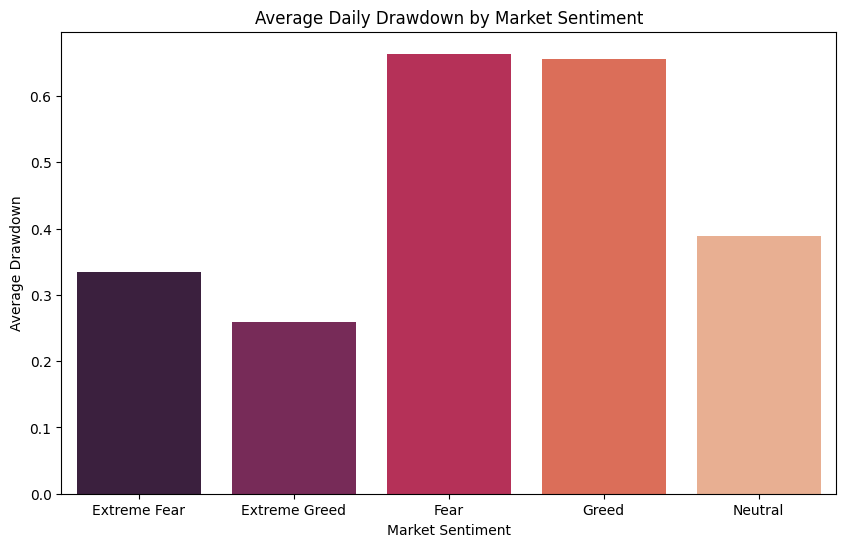

In [20]:
# Analyze Average Drawdown by sentiment classification
# We'll take the maximum daily drawdown for each account and then average by sentiment to represent the 'worst' drawdown experienced on average per sentiment type.

# To get a meaningful 'average drawdown by sentiment', we can look at the average of the maximum drawdown *experienced by each trader on days with that sentiment*.
# Or, simply the average daily drawdown under each sentiment.
# Let's start with the average daily drawdown during each sentiment classification.

# Filter out potential NaNs or infinite values that might arise from edge cases in drawdown calculation
drawdown_by_sentiment = trader_daily_metrics_sorted.groupby('classification')['Drawdown'].mean().reset_index()

print("\nAverage Daily Drawdown by Sentiment Classification:")
display(drawdown_by_sentiment)

# Plot Average Drawdown by sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Drawdown', data=drawdown_by_sentiment, palette='rocket')
plt.title('Average Daily Drawdown by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Drawdown')
plt.show()

From this analysis, we can observe if certain market sentiments lead to higher average drawdowns, indicating periods of greater capital risk for traders.

## Part D - Predictive Model for Daily PnL

To build a predictive model for future Daily PnL, we'll first aggregate our `trader_daily_metrics` to a daily level, considering the overall market sentiment for that day. Then, we'll create lagged features to capture temporal dependencies, split the data chronologically, and use a regression model to predict the next day's total PnL.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Aggregate daily metrics across all traders to get a single daily view
daily_aggregated_df = trader_daily_metrics.groupby('date').agg(
    total_daily_pnl=('Daily PnL', 'sum'),
    avg_daily_win_rate=('Daily Win Rate', 'mean'),
    avg_trade_size=('Average Trade Size USD', 'mean'),
    total_num_trades=('Number of Trades', 'sum'),
    avg_long_short_ratio=('Long/Short Ratio', lambda x: x.replace([np.inf, -np.inf], np.nan).mean()), # Handle inf again
    sentiment_value=('value', 'first'),
    sentiment_classification=('classification', 'first')
).reset_index()

# Drop rows with NaN values that might result from 'avg_long_short_ratio' or incomplete days
daily_aggregated_df.dropna(inplace=True)

# Ensure 'date' is datetime for sorting
daily_aggregated_df['date'] = pd.to_datetime(daily_aggregated_df['date'])
daily_aggregated_df.sort_values('date', inplace=True)

print("Daily Aggregated Data (first 5 rows):")
display(daily_aggregated_df.head())

Daily Aggregated Data (first 5 rows):


,date,total_daily_pnl,avg_daily_win_rate,avg_trade_size,total_num_trades,avg_long_short_ratio,sentiment_value,sentiment_classification
1,2023-12-05,0.000000,0.000000,5556.203333,9,3.500000,75.0,Extreme Greed
2,2023-12-14,-205.434737,0.363636,10291.213636,11,0.833333,72.0,Greed
5,2023-12-17,304.982785,0.500000,8305.572857,14,0.272727,73.0,Greed
7,2023-12-19,1000.538612,0.666667,6106.827333,15,0.500000,73.0,Greed
8,2023-12-20,162.732282,0.444444,7868.710556,18,1.250000,74.0,Greed


### Feature Engineering: Lagged Features and One-Hot Encoding

To predict future PnL, we'll create lagged versions of our key metrics. We'll also convert the categorical sentiment classification into numerical format using one-hot encoding.

In [22]:
# Create lagged features
# Let's use 1, 2, and 3-day lags for PnL and sentiment value
num_lags = 3
for lag in range(1, num_lags + 1):
    daily_aggregated_df[f'total_daily_pnl_lag_{lag}'] = daily_aggregated_df['total_daily_pnl'].shift(lag)
    daily_aggregated_df[f'sentiment_value_lag_{lag}'] = daily_aggregated_df['sentiment_value'].shift(lag)

# One-hot encode sentiment_classification
daily_aggregated_df = pd.get_dummies(daily_aggregated_df, columns=['sentiment_classification'], prefix='sentiment')

# Drop original sentiment columns if lagged versions are used, and other original columns if not directly used as features
# For simplicity, we'll keep the current day's sentiment_value and also use lagged PnL.
daily_aggregated_df.drop(columns=['sentiment_value'], inplace=True)

# Drop rows with NaN values created by lagging
daily_aggregated_df.dropna(inplace=True)

print("Daily Aggregated Data with Lagged Features (first 5 rows):")
display(daily_aggregated_df.head())

Daily Aggregated Data with Lagged Features (first 5 rows):


,date,total_daily_pnl,avg_daily_win_rate,avg_trade_size,total_num_trades,avg_long_short_ratio,total_daily_pnl_lag_1,sentiment_value_lag_1,total_daily_pnl_lag_2,sentiment_value_lag_2,total_daily_pnl_lag_3,sentiment_value_lag_3,sentiment_Extreme Fear,sentiment_Extreme Greed,sentiment_Fear,sentiment_Greed,sentiment_Neutral
7,2023-12-19,1000.538612,0.666667,6106.827333,15,0.500000,304.982785,73.0,-205.434737,72.0,0.000000,75.0,False,False,False,True,False
8,2023-12-20,162.732282,0.444444,7868.710556,18,1.250000,1000.538612,73.0,304.982785,73.0,-205.434737,72.0,False,False,False,True,False
9,2023-12-21,537.211402,0.530612,2555.795306,49,0.814815,162.732282,74.0,1000.538612,73.0,304.982785,73.0,False,False,False,True,False
10,2023-12-22,141.832675,0.200000,8887.428000,10,4.000000,537.211402,70.0,162.732282,74.0,1000.538612,73.0,False,False,False,True,False
11,2023-12-23,146.936704,0.615385,6033.711538,13,0.625000,141.832675,74.0,537.211402,70.0,162.732282,74.0,False,False,False,True,False


### Data Splitting for Time Series Prediction

We will split the data chronologically, using an 80/20 split for training and testing to ensure that our model predicts future values based on past data.

In [23]:
# Define features (X) and target (y)
X = daily_aggregated_df.drop(columns=['date', 'total_daily_pnl'])
y = daily_aggregated_df['total_daily_pnl']

# Split data into training and testing sets (chronological split)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print("Features used for training (first 5):")
display(X_train.head())

Training set size: 352 samples
Testing set size: 89 samples
Features used for training (first 5):


,avg_daily_win_rate,avg_trade_size,total_num_trades,avg_long_short_ratio,total_daily_pnl_lag_1,sentiment_value_lag_1,total_daily_pnl_lag_2,sentiment_value_lag_2,total_daily_pnl_lag_3,sentiment_value_lag_3,sentiment_Extreme Fear,sentiment_Extreme Greed,sentiment_Fear,sentiment_Greed,sentiment_Neutral
7,0.666667,6106.827333,15,0.500000,304.982785,73.0,-205.434737,72.0,0.000000,75.0,False,False,False,True,False
8,0.444444,7868.710556,18,1.250000,1000.538612,73.0,304.982785,73.0,-205.434737,72.0,False,False,False,True,False
9,0.530612,2555.795306,49,0.814815,162.732282,74.0,1000.538612,73.0,304.982785,73.0,False,False,False,True,False
10,0.200000,8887.428000,10,4.000000,537.211402,70.0,162.732282,74.0,1000.538612,73.0,False,False,False,True,False
11,0.615385,6033.711538,13,0.625000,141.832675,74.0,537.211402,70.0,162.732282,74.0,False,False,False,True,False


### Model Training and Evaluation

We will use a RandomForestRegressor, a robust machine learning model suitable for this type of prediction task. After training, we'll evaluate its performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared.


Model Performance:
Mean Absolute Error (MAE): 77597.88
Root Mean Squared Error (RMSE): 115764.95
R-squared (R2): 0.05


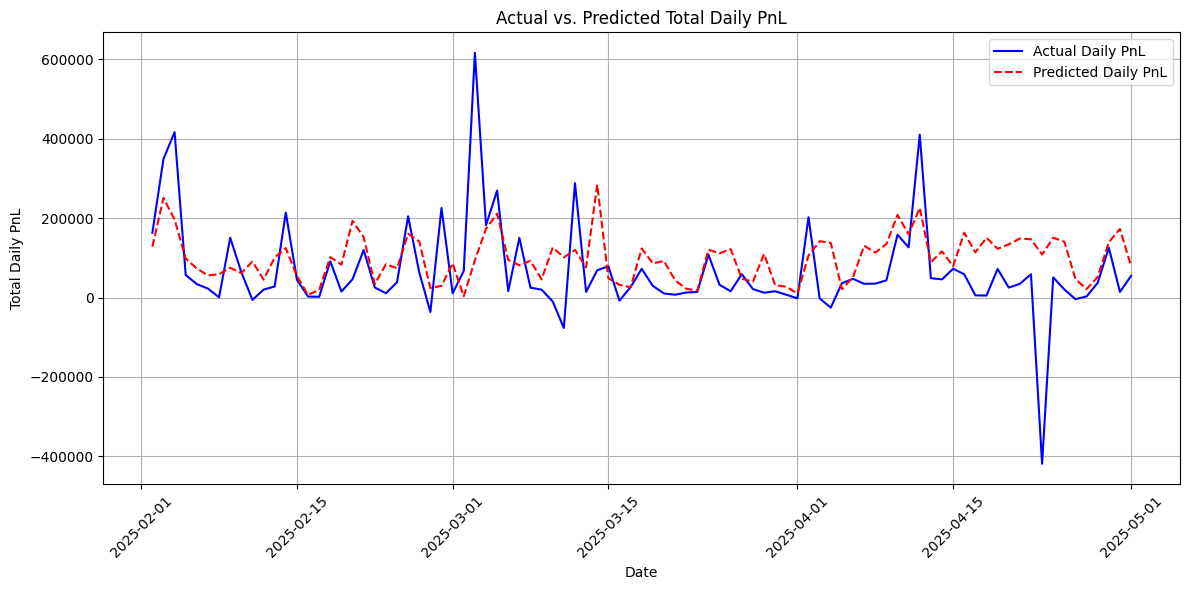

In [24]:
# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(daily_aggregated_df['date'][split_index:], y_test, label='Actual Daily PnL', color='blue')
plt.plot(daily_aggregated_df['date'][split_index:], y_pred, label='Predicted Daily PnL', color='red', linestyle='--')
plt.title('Actual vs. Predicted Total Daily PnL')
plt.xlabel('Date')
plt.ylabel('Total Daily PnL')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This predictive model provides insights into how well we can forecast total daily PnL based on past performance and market sentiment. The evaluation metrics (MAE, RMSE, R2) and the plot of actual vs. predicted values will give us an idea of the model's accuracy.